In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
INPUT_FILE = './new_code_results.csv'
# plot the results from input file
df = pd.read_csv(INPUT_FILE)
df = df.sort_values(by='PROBABILITY')
print(df)

   PROBABILITY  MAE_overall  MAE_reward_minus_1  MAE_reward_0  MAPE_positive
1          0.1     0.007250            0.033758      0.003655       2.263622
2          0.3     0.005707            0.008145      0.000292       1.433785
0          0.5     0.018032            0.014166      0.003502       2.583470
3          0.7     0.013081            0.021030      0.008070       0.466936
4          0.9     0.021135            0.004079      0.037563       1.722527


In [6]:
probabilities = df['PROBABILITY']
mae_overall_list = df['MAE_overall']
mae_neg1_list = df['MAE_reward_minus_1']
mae_zero_list = df['MAE_reward_0']
mape_positive_list = df['MAPE_positive']

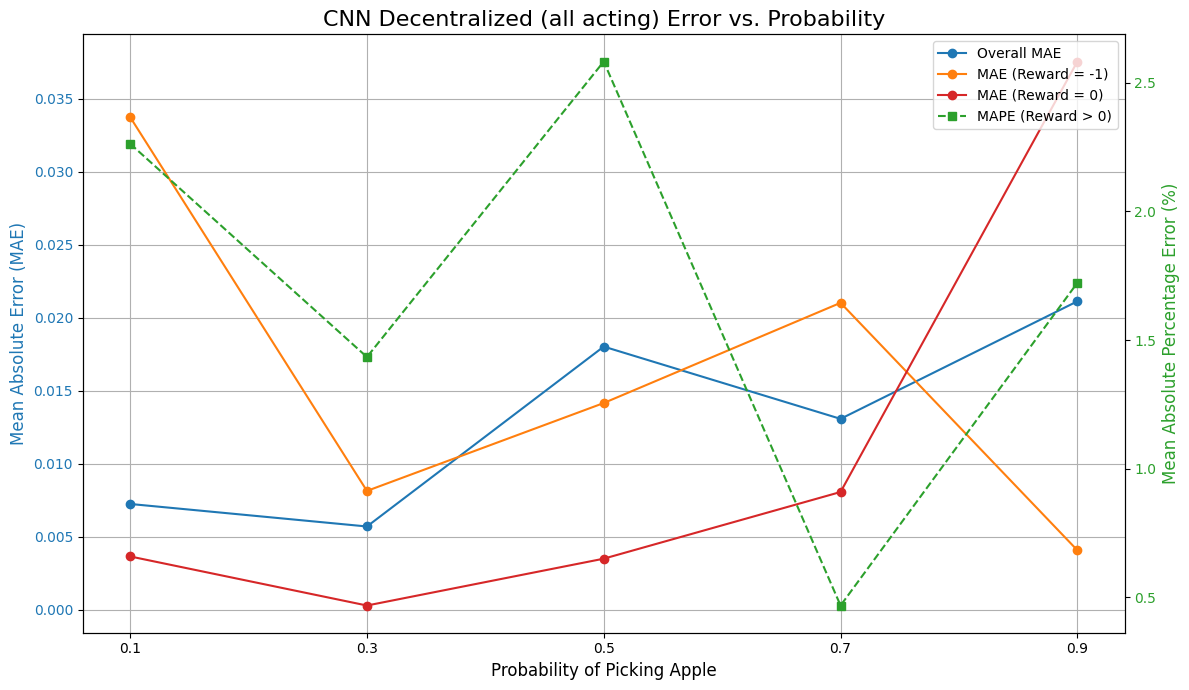

In [7]:

# Plot the results
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot the MAE values on the primary (left) y-axis
ax1.plot(probabilities, mae_overall_list, marker="o", label="Overall MAE", color='tab:blue')
ax1.plot(probabilities, mae_neg1_list, marker="o", label="MAE (Reward = -1)", color='tab:orange')
ax1.plot(probabilities, mae_zero_list, marker="o", label="MAE (Reward = 0)", color='tab:red')
ax1.set_xlabel("Probability of Picking Apple", fontsize=12)
ax1.set_ylabel("Mean Absolute Error (MAE)", color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Create a second y-axis for the MAPE values
ax2 = ax1.twinx()
ax2.plot(probabilities, mape_positive_list, marker="s", linestyle='--', label="MAPE (Reward > 0)", color='tab:green')
ax2.set_ylabel("Mean Absolute Percentage Error (%)", color='tab:green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends from both axes for clarity
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.title("CNN Decentralized (all acting) Error vs. Probability", fontsize=16)
plt.xticks(probabilities)
fig.tight_layout()